In [5]:
import pickle

import matplotlib.pyplot as plt
import numpy as np

In [6]:
with open('A1-EXP2-prob-vs-rand-rss64-128/rand/testACCs.pck', 'rb') as f:
    acc1 = pickle.load(f)
    
with open('A1-EXP2-prob-vs-rand-rss64-128/prob/testACCs.pck', 'rb') as f:
    acc2 = pickle.load(f)
    
with open('A1-EXP2-prob-vs-rand-rss64-128/prob_amp/testACCs.pck', 'rb') as f:
    acc3 = pickle.load(f)
    
# acc1 = [sublist[:80] for sublist in acc1]
# acc2 = [sublist[:80] for sublist in acc2]
# acc3 = [sublist[:80] for sublist in acc3]

In [7]:
def calculate_column_averages(data):
    columns = zip(*data)
    averages = [sum(column) / len(column) for column in columns]
    return averages

# Get averages
acc1 = calculate_column_averages(acc1)
acc2 = calculate_column_averages(acc2)
acc3 = calculate_column_averages(acc3)

acc1 = [sum(acc1[i:i+5]) / 5 for i in range(len(acc1) - 4)]
acc1 = [None] * 4 + acc1

acc2 = [sum(acc2[i:i+5]) / 5 for i in range(len(acc2) - 4)]
acc2 = [None] * 4 + acc2

acc3 = [sum(acc3[i:i+5]) / 5 for i in range(len(acc3) - 4)]
acc3 = [None] * 4 + acc3


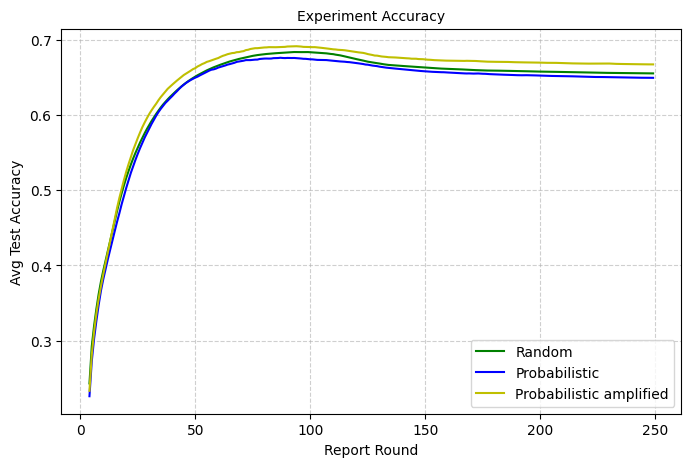

In [8]:
fig, ax1 = plt.subplots(figsize=(8, 5))

# loss
ax1.plot(acc1, linestyle='-', color='g', label='Random')
ax1.plot(acc2, linestyle='-', color='b', label='Probabilistic')
ax1.plot(acc3, linestyle='-', color='y', label='Probabilistic amplified')
ax1.set_title("Experiment Accuracy", fontsize=10)
ax1.set_xlabel("Report Round", fontsize=10)
ax1.set_ylabel("Avg Test Accuracy", fontsize=10, color='k')
ax1.tick_params(axis='y', labelcolor='k')
ax1.grid(True, linestyle='--', alpha=0.6)

plt.legend()
plt.show()

In [9]:
print(acc1[-1])
print(acc2[-1])
# print(acc3[-1])


0.65554
0.6496419999999999


# Replot exp results

In [ ]:
from createPlot import createLossAccPlot

createLossAccPlot("FedDC_cifar10_iidrandsize8_64nc150cl_n64_b64_d1_a10_r5000_s1_2024-12-02_09-46-46rand")

In [ ]:
createLossAccPlot("FedDC_cifar10_iidrandsize8_64nc150cl_n64_b64_d1_a100_r5000_s1_2024-12-02_21-27-40rand")

# Random Client Sample Size Visualisation

In [ ]:
from matplotlib.ticker import MaxNLocator

client_idxs = [[1,2,3,4,5],
               [1,2,3],
               [1,2,3,4,5,6,7,7,8],
               [2,25,2,3,346,2,34,3,346,34,6,4],
               [1,2,3,4,5],
               [1,2,3]]

visits = [1,0,3,9,3,2]

def plot_rss(client_idxs, visits, path):
    counts = []
    for l in client_idxs:
        counts.append(len(l))
    # counts.sort()
    
    combined = sorted(zip(counts, visits), key=lambda x: x[0])

    # Separate the sorted lists
    sorted_counts, sorted_visits = zip(*combined)
    
    # Convert back to lists
    counts = list(sorted_counts)
    visits = list(sorted_visits)


    fig, ax1 = plt.subplots(figsize=(16, 8))

    # Bar plot for sample size
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax1.bar(np.arange(len(counts)), counts, label='Sample Size', alpha=0.7, color='blue')
    ax1.set_title("Client Sample Size")
    ax1.set_xlabel("Client")
    ax1.set_ylabel("Sample Size", color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')

    # Create second y-axis for visits
    ax2 = ax1.twinx()
    ax2.plot(np.arange(len(visits)), visits, label='Visits', color='red', marker='o')
    ax2.set_ylabel("Visits", color='red')
    ax2.tick_params(axis='y', labelcolor='red')

    # Adding legends for both plots
    fig.legend(loc="upper right", bbox_to_anchor=(1, 1), bbox_transform=ax1.transAxes)

    # Save and display the plot
    plt.savefig(path)
    plt.show()

plot_rss(client_idxs, visits, "")